In [594]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt


In [595]:
def build_float_to_boolean_encoder_only_voltage():
    input_layer = tf.keras.Input(shape=(1,), name="float_input")

    # Create a normalization layer
    norm = layers.Normalization(axis=-1)
    # We'll adapt this normalization layer on the data later.
    x = norm(input_layer)

    # 2) Multiple Dense layers with ReLU
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)  # 20% dropout for regularization
    x = layers.Dense(16, activation='relu')(x)
    x = layers.Dropout(0.2)(x)  # another dropout

    # 3) Final Dense layer (3 outputs), each with a sigmoid for binary classification
    outputs = layers.Dense(3, activation='sigmoid')(x)

    # 4) Build the model
    model = Model(inputs=input_layer, outputs=outputs)

    # 5) Compile the model (binary_crossentropy for multiple binary outputs)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']  # This tracks how many individual bits match 0/1, not perfect for multi-bit, but still helpful
    )

    # Return both the model and the normalization layer (we need to .adapt() it)
    return model, norm




In [596]:
def build_float_to_boolean_encoder():
    # 1) Input layer for two float inputs
    input_layer = tf.keras.Input(shape=(2,), name="float_input")  # Shape (batch_size, 2)

    # Create a normalization layer
    norm = layers.Normalization(axis=-1)  # Normalizes each feature independently
    # We'll adapt this normalization layer on the data later.
    x = norm(input_layer)

    # 2) Multiple Dense layers with ReLU
    x = layers.Dense(32, activation='relu')(x)
   # x = layers.Dropout(0.2)(x)  # 20% dropout for regularization
    x = layers.Dense(16, activation='relu')(x)
    #x = layers.Dropout(0.2)(x)  # another dropout

    # 3) Final Dense layer (3 outputs), each with a sigmoid for binary classification
    outputs = layers.Dense(3, activation='sigmoid')(x)

    # 4) Build the model
    model = Model(inputs=input_layer, outputs=outputs)

    # 5) Compile the model (binary_crossentropy for multiple binary outputs)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']  # Tracks the accuracy of individual bits (0/1)
    )

    # Return both the model and the normalization layer (we'll adapt it later)
    return model, norm



In [597]:
# Path to the folder containing the CSV files
def readDatasInPanda(file_paths):
#we probaply should not combine all the files in one dataset just now for testing
    folder_path = 'data'
    dataframes = []
    for file_path in file_paths: 
        print("read: " + file_path)
        df = pd.read_csv(file_path)
        
        # Append the cleaned DataFrame to the list
        dataframes.append(df)

# Combine all DataFrames into one
        pandas_data = pd.concat(dataframes, ignore_index=True)

# Display the first few rows of the combined DataFrame
    return pandas_data

In [598]:
df = readDatasInPanda(["./data/Circuit_Scenario4_res.csv", "./data/Circuit_Scenario5_res.csv", "./data/Circuit_Scenario6_res.csv", "./data/Circuit_Scenario7_res.csv",
                      "./data/Circuit_Scenario8_res.csv"])
df = readDatasInPanda(["./data/Circuit_Scenario8_res.csv"])

read: ./data/Circuit_Scenario4_res.csv
read: ./data/Circuit_Scenario5_res.csv
read: ./data/Circuit_Scenario6_res.csv
read: ./data/Circuit_Scenario7_res.csv
read: ./data/Circuit_Scenario8_res.csv
read: ./data/Circuit_Scenario8_res.csv


In [599]:
y = df[["circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values
# Convert output column to float as well:
X = df[["circ1.r_load.v", "circ1.r_load.r_int"]].astype(float).values
Y_binary = y - 1.0

#X

Model: "model_50"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 float_input (InputLayer)    [(None, 2)]               0         
                                                                 
 normalization_50 (Normaliza  (None, 2)                5         
 tion)                                                           
                                                                 
 dense_186 (Dense)           (None, 32)                96        
                                                                 
 dense_187 (Dense)           (None, 16)                528       
                                                                 
 dense_188 (Dense)           (None, 3)                 51        
                                                                 
Total params: 680
Trainable params: 675
Non-trainable params: 5
____________________________________________________________

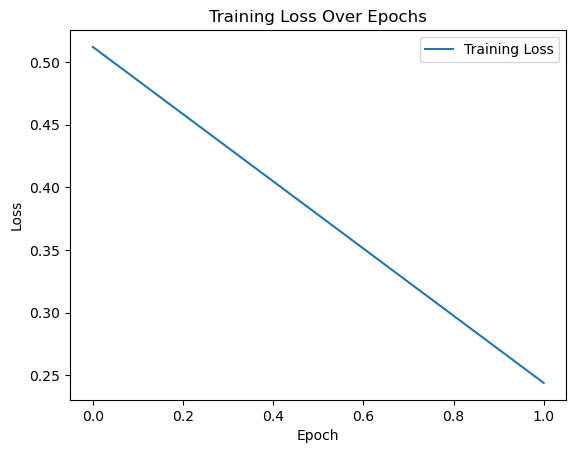

In [600]:
model, norm_layer = build_float_to_boolean_encoder()

    # We must "adapt" the normalization layer on our training data
norm_layer.adapt(X)

    # Print a summary
model.summary()

    # Train/fit the model
history = model.fit(
    X, 
    Y_binary, 
    epochs=2,        # Feel free to increase epochs
    batch_size=4,
    verbose=1
)

    # Optional: Plot the training loss over epochs
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

   

In [603]:
single_input = X[190]  # This is a single value, shape = (1,)

# Reshape to add batch dimension
single_input = single_input.reshape(1, -1)  # Shape = (1, 1)

# Predict for the single input
single_pred = model.predict(single_input)
preds_binary = (single_pred > 0.5).astype(int)
print("Raw Prediction:", preds_binary)


1/1 [==============================] - 0s 16ms/step
Raw Prediction: [[1 0 0]]


In [604]:
X = X.reshape(-1, 1)
preds_raw = model.predict(X)  # shape = (num_samples, 3)
    # Threshold at 0.5 => 0 or 1

#preds_raw

23/23 [==============================] - 0s 706us/step


In [605]:
#predict faults. 
df_d = readDatasInPanda(["./data/Circuit_Scenario10_res.csv"])
#df_d

read: ./data/Circuit_Scenario10_res.csv


In [606]:
y_d = df_d[["circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values
# Convert output column to float as well:
X_d = df_d[["circ1.r_load.v", "circ1.r_load.r_int"]].astype(float).values
Y_binary_d = y_d - 1.0
#X_d

In [607]:
X_d = X_d.reshape(-1, 1)
preds_raw_d = model.predict(X_d)
preds_binary_d = (preds_raw_d > 0.5).astype(int)




2/2 [==============================] - 0s 2ms/step


In [609]:
#Compare prediction with fact 
for elem in preds_binary_d:
    print(preds_binary_d)


[[1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]]
[[1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]]
[[1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]